In [1]:
from hcipy import *
import numpy as np
import matplotlib.pyplot as plt
import scipy.ndimage as ndimage
from matplotlib.animation import FFMpegWriter
from tqdm.notebook import tqdm
import astropy.io.fits as fits
from pathlib import Path, PosixPath
import math
from scipy.interpolate import interp1d
#from speclite import filters1
import scipy.integrate as integrate
from shackhartmann import MySquareShackHartmannWavefrontSensorOptics
from transmitted_power import transmitted_power
from csv import DictWriter
from noisydetector import MyNoisyDetector, MyNoiselessDetector

In [40]:
# some telescope parameters

telescope_diameter = 0.8 #m
focal_length = 5.6 #m
platescale = 206265 / focal_length #arcsec/m
fov_sci = 2 # arcsec

spider_width = 0.02 # m this is a guess
num_spiders = 4
central_obscuration = 0.1558 # meter
central_obscuration_ratio = central_obscuration / telescope_diameter
oversizing_factor = 16 / 16
area_aperture = math.pi*(telescope_diameter/2)**2 - math.pi*(central_obscuration/2)**2 - 0.5*(telescope_diameter-central_obscuration)*spider_width*num_spiders # m^2

px_per_subap = 3
num_lenslets = 10
num_pupil_pixels = px_per_subap * num_lenslets * oversizing_factor # 10 subapertures along one side with 3 pixels along one side 
pupil_diameter = telescope_diameter * oversizing_factor

In [41]:
# transmission loss parameters

n_telescope_mirrors = 3
n_ao_mirrors = 7

target_spectrum_file = Path('LEO_spectrum_mag5.fits') # can be .fits or .csv
telescope_coating_file = Path('protected_aluminium_ZimMAIN.csv') #microns
ao_coating_file = Path('protected_aluminium_ZimMAIN.csv')
#qe_file = Path('qe_curve.csv') # angstr; asked ChatGPT to make arrays from an image of QE curve for Oxford Instr. OCAM2K camera 

In [42]:
# make a telescope pupil

pupil_grid = make_pupil_grid(num_pupil_pixels, diameter=pupil_diameter)
pupil_aperture_generator = make_obstructed_circular_aperture(telescope_diameter, 
                                                             central_obscuration_ratio, 
                                                             num_spiders=num_spiders, 
                                                             spider_width=spider_width)
telescope_pupil = evaluate_supersampled(pupil_aperture_generator, pupil_grid, 4)
#telescope_pupil.grid.weights = np.array(24e-6).astype('float') #24e-6 # size of one pupil pixel in m
#print(pupil_grid.delta)
print((pupil_diameter/num_pupil_pixels)**2) # size of one pupil pixel in telescope pupil plane in m^2

0.0007111111111111113


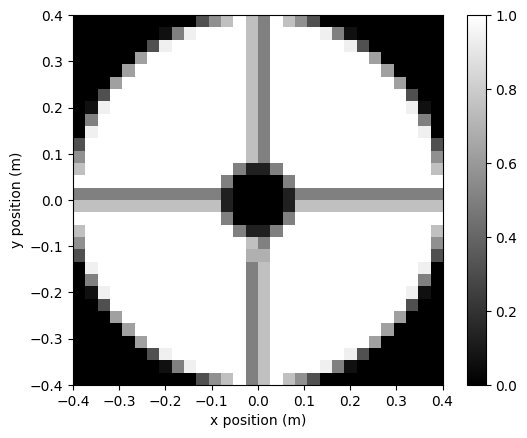

In [43]:
imshow_field(telescope_pupil, cmap='gray') # this does not display the weight, just the field value
plt.xlabel('x position (m)')
plt.ylabel('y position (m)')
plt.colorbar()
plt.show()

In [44]:
# make an atmosphere

seeing = 1.25 # arcsec @ 500nm (convention) -> r0 = 10.1cm
outer_scale = 40 # meter
tau0 = 0.01 # seconds - assumption

fried_parameter = seeing_to_fried_parameter(seeing)
Cn_squared = Cn_squared_from_fried_parameter(fried_parameter, 500e-9)
velocity = 0.314 * fried_parameter / tau0 # this is a formula cited by various sources, not sure where the coefficient was born from

layer = InfiniteAtmosphericLayer(pupil_grid, Cn_squared, outer_scale, velocity)

In [4]:
fried_parameter_to_seeing(0.06)
seeing_to_fried_parameter(1.5)

np.float64(0.0673798367073848)

In [45]:
# get target light
hdu = fits.open(target_spectrum_file)
target_wavelength, target_flux = hdu[1].data['WAVELENGTH'], hdu[1].data['FLUX'] #angstroms, FLAM (erg * s^-1 * cm^-2 * angstr^-1)
target_power = target_flux*area_aperture*1e4 # erg * s^-1 * angstr^-1

In [46]:
# reduce target light transmission due to surfaces in telescope and AO

wavelength_crop1, transmitted_power_telescope = transmitted_power(wavelength = target_wavelength, 
                                                                  in_power = target_power,
                                                                  transmission_file = telescope_coating_file,
                                                                  n_surfaces = n_telescope_mirrors)

wavelength_crop2, transmitted_power_ao = transmitted_power(wavelength = wavelength_crop1, 
                                                         in_power = transmitted_power_telescope,
                                                         transmission_file = ao_coating_file,
                                                         n_surfaces = n_ao_mirrors)

In [100]:
# make wavefronts for after propagation through telescope & AO surfaces

wavefronts_target = []
for i, wlen in enumerate(wavelength_crop2): # telescope_pupil has values 1 or 0 (like a mask), and weights of pixel size in m^2
    wf = Wavefront(telescope_pupil, wlen*1e-10) # HCIPy wavefronts take wavelengths in meters only!
    # if i == 0:
    #     print(wf.total_power, area_aperture) # these two values approximately the same, the left is slightly smaller
    # WF electric field = telescope_pupil (values 1 or 0)
    # WF power = electric field^2 * weights = electric field^2 * size of one pupil pixel (telescope pupil plane!)
    # total power = electric_field^2 * area_aperture = sum(pixel power)
    wf.total_power = transmitted_power_ao[i] # erg * s^-1 * angstr^-1 - this already contains the multiplication by the aperture area
    wavefronts_target.append(wf)
# make wavefront arrays
target_wlens = np.array([wf.wavelength for wf in wavefronts_target])
target_powers = np.array([wf.total_power for wf in wavefronts_target]) 

# split wavefronts for WFS and Science Camera

# WFS beam
wavelength_wfs = 5750e-10 # m. - reference, central wavelength
wfs_bandwidth = 500e-10
wfs_beamsplit = 1 # between 0 (no light) and 1 (all of the light)

# science camera beam
wavelength_sci = 4750e-10 # m - central wavelength
sci_bandwidth = 1500e-10

#target_wavelength
wfs_min, wfs_max = wavelength_wfs - wfs_bandwidth/2, wavelength_wfs + wfs_bandwidth/2
wfs_wavefronts = np.array(wavefronts_target)[(target_wlens > wfs_min) & (target_wlens < wfs_max)]
for wf in wfs_wavefronts:
    wf.total_power = wfs_beamsplit*np.array(target_powers)[(target_wlens == wf.wavelength)][0]
wfs_wls = [wf.wavelength*1e10 for wf in wfs_wavefronts] # convert wavelengths back to angstrom for plotting
wfs_power = [wf.total_power for wf in wfs_wavefronts]

target_copy2 = wavefronts_target.copy()
sci_min, sci_max = wavelength_sci - sci_bandwidth/2, wavelength_sci + sci_bandwidth/2
sci_wavefronts = np.array(wavefronts_target)[(target_wlens > sci_min) & (target_wlens < sci_max)]
for wf in sci_wavefronts:
    if (wf.wavelength < wfs_max) and (wf.wavelength > wfs_min):
        wf.total_power = (1 - wfs_beamsplit)*np.array(target_powers)[(target_wlens == wf.wavelength)][0]
sci_wls = np.array([wf.wavelength*1e10 for wf in sci_wavefronts]) # convert wavelengths back to angstrom for plotting
sci_power = np.array([wf.total_power for wf in sci_wavefronts])


In [101]:
print(f'Power per frame in WFS at 1kHz: {integrate.simpson(wfs_power, wfs_wls)*0.001*1e8:.1f}e-8 ergs') # check consistency with exposure time calculator!

Power per frame in WFS at 1kHz: 2.4e-8 ergs


(0.0, 1.5e-07)

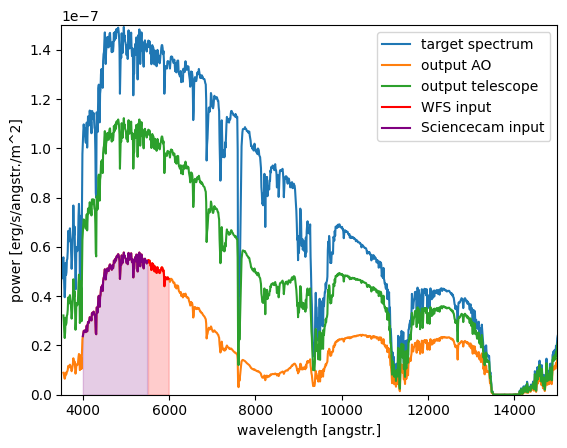

In [102]:
plt.plot(target_wavelength, target_power, label = 'target spectrum')
plt.plot(wavelength_crop2, transmitted_power_ao, label = 'output AO')
plt.plot(wavelength_crop1, transmitted_power_telescope, label='output telescope')
plt.plot(wfs_wls, wfs_power, color='red', label = 'WFS input')
plt.fill_between(wfs_wls, wfs_power, color = 'red', alpha=0.2)
plt.plot(sci_wls, sci_power, color = 'purple', label = 'Sciencecam input')
plt.fill_between(sci_wls, sci_power, color = 'purple', alpha=0.2)
plt.plot()
plt.legend()
plt.xlabel('wavelength [angstr.]')
plt.ylabel('power [erg/s/angstr./m^2]')
plt.xlim(3500, 15000)
plt.ylim(0,1.5e-7)

In [103]:
# make focal plane

spatial_res = 1.22 * sci_max * focal_length / telescope_diameter # all variables use meters
num_airy = fov_sci/platescale / spatial_res
sci_cam_px_size = 2.9e-6 # meters / px, assuming same pixel size as current LEO camera
q = math.ceil(spatial_res / sci_cam_px_size)
focal_grid_sci = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_res)
# q = number of pixels between rings, num_airy = number of rings that should be visible
n_pixels_sci = len(focal_grid_sci.coords[0])
print(f'{n_pixels_sci=}, along one side: {np.sqrt(n_pixels_sci)}')

print(f"expected number of visible airy disks: {round(num_airy,1)}, expected spatial extent of focal plane: {round(spatial_res*num_airy/1e-6, 1)}µm, pixels per spot: {q}")

n_pixels_sci=2116, along one side: 46.0
expected number of visible airy disks: 11.6, expected spatial extent of focal plane: 54.3µm, pixels per spot: 2


In [104]:
prop = FraunhoferPropagator(pupil_grid, focal_grid_sci, focal_length=focal_length)

In [105]:
# put a camera in the Science beam

sci_camera = NoiselessDetector(focal_grid_sci)
sci_camera2 = NoiselessDetector(focal_grid_sci)

sci_exp_time = 1 # seconds

In [106]:
h = 6.626e-27 # erg * s
c = 3e5 * 1e13 # Angstrom / s

In [107]:
# propagate wavefront from pupil to focal plane (for the Science beam) - once without atmosphere, once with it

counts_per_angstr_ref = np.zeros((len(sci_wavefronts), n_pixels_sci))
counts_per_angstr_calm = np.zeros((len(sci_wavefronts), n_pixels_sci))
counts_per_angstr_turb = np.zeros((len(sci_wavefronts), n_pixels_sci))

photon_counts_total2 = []

for i, wf in enumerate(sci_wavefronts):

    E_photon = h * c / (wf.wavelength*1e10) # [erg]

    prop_wf = prop.forward(wf)

    accumulated_energy = prop_wf.power * sci_exp_time # [erg * angstr^-1]
    counts_per_angstr_ref[i] = accumulated_energy / E_photon # counts/angstr

    # without atmosphere - this will be used later as reference-PSF to compute the Strehl ratio in AO simulation
    sci_camera.integrate(prop_wf, sci_exp_time) # adds wf.power * exp_time to the camera's accumulated_charge attribute
    data1 = sci_camera.read_out() # erg * angstr^-1
    counts_per_angstr_calm[i] = data1 / E_photon
    
    # with atmosphere
    sci_camera.integrate(prop.forward(layer(wf)), sci_exp_time)
    data2 = sci_camera.read_out()
    counts_per_angstr_turb[i] = data2 / E_photon 

    photon_counts_total2.append(np.sum(data1 / E_photon))

photon_in_cam = integrate.simpson(photon_counts_total2, sci_wls)
print(f'Expecting {round(photon_in_cam*1e-6, 2)}e6 photons/s in the Science Camera at {int(sci_min*1e10)}-{int(sci_max*1e10)} Angstroms, {round(photon_in_cam/n_pixels_sci,1)} photons per px.')

photon_counts_calm = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_sci)
photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_sci)
photon_counts_ref = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_sci)

for i in range(len(counts_per_angstr_ref[0])): # loop over pixels, integrate all wavelengths
    photon_counts_ref[i] = integrate.simpson(counts_per_angstr_ref[:, i], sci_wls)
    photon_counts_calm[i] = integrate.simpson(counts_per_angstr_calm[:, i], sci_wls)
    photon_counts_turb[i] = integrate.simpson(counts_per_angstr_turb[:, i], sci_wls)


Expecting 17.02e6 photons/s in the Science Camera at 4000-5500 Angstroms, 8043.6 photons per px.


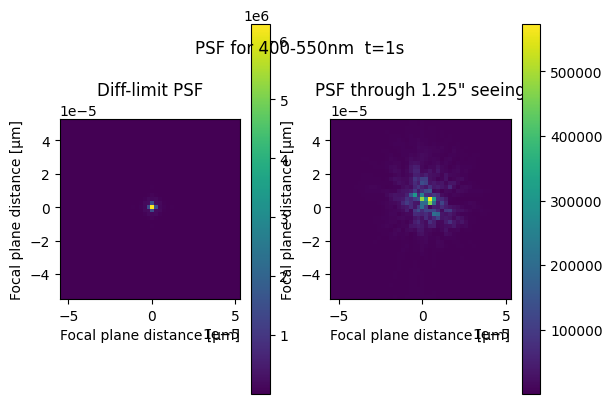

In [108]:
plt.suptitle(f'PSF for {int(sci_min*1e9)}-{int(sci_max*1e9)}nm  t={round(sci_exp_time,3)}s', y= 0.85)

plt.subplot(1,2,1)
plt.title('Diff-limit PSF')
imshow_field(photon_counts_calm)#, vmin = -6, vmax=0, grid_units=1e-6)
plt.xlabel('Focal plane distance [µm]')
plt.ylabel('Focal plane distance [µm]')
plt.colorbar()

plt.subplot(1,2,2)
plt.title(f'PSF through {seeing}" seeing')
imshow_field(photon_counts_turb)#, vmin = -6, vmax=0, grid_units=1e-6)
plt.xlabel('Focal plane distance [µm]')
plt.ylabel('Focal plane distance [µm]')
plt.colorbar()

plt.show()

In [109]:
strehl = get_strehl_from_focal(photon_counts_turb, photon_counts_calm)
print(strehl)

0.03295576061326328


In [110]:
# set SH-WFS parameters

px_size = 24e-6 #m - Armasuisse report cameras
#px_scale = 5/2 # arcsec / px  -- can compare this to diff_limit_wfs for different wavelengths, 
# somewhere between diff limit telescope and diff limit wfs, want it to be below seeing size to be sensitive to seeing
fov_wfs = 5 # arcsec - minimum for structure
px_scale = fov_wfs / px_per_subap
#px_per_subap = fov_wfs / px_scale # 9 px

num_lenslets = math.ceil(telescope_diameter / fried_parameter) # along one side
if num_lenslets%2 == 1:
    num_lenslets += 1 # make sure it's an even number so the spiders don't obscure so much light
num_lenslets = 10 # result for 1.25" seeing. 12 subaps might be stretching light thin

wavelength_percentile_to_scale = 0.5 # which wavelength we want to fit - 0 (bluest), 1 (all light), 0.5 (mean)
wlen_to_scale_into_px = wfs_min + wfs_bandwidth*wavelength_percentile_to_scale

diff_limit_telescope = 1.22 * wlen_to_scale_into_px / telescope_diameter * 206265 # arcsec
physical_spot_size_telescope = diff_limit_telescope / platescale 

diff_limit_wfs = diff_limit_telescope * num_lenslets # TODO this gives something different than the definition below.
# the following is wrong bc. it forgets the magnification: 1.22 * wlen_to_scale_into_px / sh_diameter * 206265 
#diff_limit_wfs = physical_spot_size_SH * platescale_sh  # 
n_px_one_spot = round(diff_limit_wfs / px_scale,0)

physical_spot_size_SH = n_px_one_spot * px_size

sh_diameter = px_size * px_per_subap * num_lenslets 
lenslet_diameter = px_size * px_per_subap
magnification_pupil = sh_diameter / telescope_diameter 

f_coll = focal_length * magnification_pupil

magnification_focal = physical_spot_size_SH / physical_spot_size_telescope

f_sh = f_coll * magnification_focal
f_number = f_sh / sh_diameter # physical_spot_size_SH / wlen_to_scale_into_px # different by a factor of 1.22 #
platescale_sh = platescale / magnification_focal # the following is wrong bc. it forgets the magnification: 206265 / f_sh

#fov_wfs = diff_limit_wfs * px_per_subap # platescale_sh * lenslet_diameter
print(f'''        {fried_parameter=:.2f}m
        {num_lenslets=}
        {px_per_subap=}
        {diff_limit_wfs=:.2f}"
        {f_number=:.2f}
        {fov_wfs=:.2f}"
        {sh_diameter=:f}m
        {wlen_to_scale_into_px=}m
        {physical_spot_size_SH=}m
        {magnification_pupil=}
        {n_px_one_spot=}
        {px_scale=}"/px''')

        fried_parameter=0.08m
        num_lenslets=10
        px_per_subap=3
        diff_limit_wfs=1.81"
        f_number=34.21
        fov_wfs=5.00"
        sh_diameter=0.000720m
        wlen_to_scale_into_px=5.75e-07m
        physical_spot_size_SH=2.4e-05m
        magnification_pupil=0.0009
        n_px_one_spot=1.0
        px_scale=1.6666666666666667"/px


In [111]:
# make a SH-WFS using above parameters

num_pupil_pixels = (num_lenslets*px_per_subap) * oversizing_factor # oversizing_factor=1 atm
pupil_grid = make_pupil_grid(num_pupil_pixels, diameter=pupil_diameter)
magnifier = Magnifier(magnification_pupil)
#print((np.sqrt(pupil_grid.weights)*magnification_pupil)**2, (24e-6)**2)

shwfs = MySquareShackHartmannWavefrontSensorOptics(pupil_grid.scaled(magnification_pupil), 
                                                 f_number, 
                                                 num_lenslets, 
                                                 sh_diameter)

#print(pupil_grid.scaled(magnification_pupil).weights) # area of pixel in m^2 - it's correct.

# I wrote a separate SHWFS class so that the MLA does not center the central lenslet row right onto the spiders which obscure them
# This new class also fixes a bug in their code where the MLA diameter is double the pupil diameter.


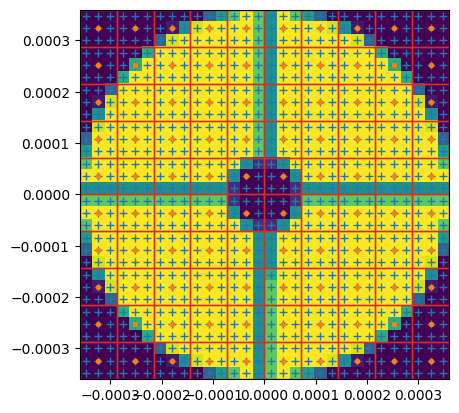

In [112]:
# plot SH-WFS

pupil_aperture_generator_wfs = make_obstructed_circular_aperture(telescope_diameter*magnification_pupil, 
                                                             central_obscuration_ratio, 
                                                             num_spiders=num_spiders, 
                                                             spider_width=spider_width*magnification_pupil)

grid2 = pupil_grid.scaled(magnification_pupil)
plt.plot(grid2.x, grid2.y, '+', label = 'scaled pupil grid')
imshow_field(evaluate_supersampled(pupil_aperture_generator_wfs, grid2, 4))
grid = shwfs.mla_grid 
for p in grid.points:
    d = grid.x[1]-grid.x[0]
    rect = plt.Rectangle(p - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.plot(shwfs.mla_grid.x, shwfs.mla_grid.y, '.', label = 'MLA')
plt.gca().set_aspect(1)
plt.show()

In [113]:
# make focal plane for SH
#spatial_res = physical_spot_size_SH #m/px 
#num_airy = fov_wfs / px_scale / 2 * num_lenslets
#q = n_px_one_spot # adjust this sh_sampling
#focal_grid_wfs = make_focal_grid(q=q, num_airy=num_airy, spatial_resolution=spatial_res)
#print(np.sqrt(len(focal_grid_wfs.coords[0])))

focal_grid_wfs = pupil_grid.scaled(magnification_pupil)
n_pixels_wfs = len(focal_grid_wfs.coords[0])
print('Hi')
print(np.sqrt(n_pixels_wfs))

Hi
30.0


In [114]:
# put a camera behind the WFS, choose its exposure time

camera = NoiselessDetector(focal_grid_wfs) #, read_noise=0, dark_current_rate=0, include_photon_noise=False) # includes photon noise

operation_freq = 1e3 #Hz
wfs_exp_time = 1 / operation_freq

#camera.integrate(shwfs(magnifier(wf)), wfs_exp_time)

In [115]:
# read out WFS image, once without atmosphere, then with 

# the wavefront electric field is defined on the pupil grid, it's value is the sqrt of the power
# when sent through the magnifier, wavefront electic field is redefined on the magnified pupil grid 
# and the wavefront electric field is divided by sqrt(magnification)

counts_per_angstr_ref = np.zeros((len(wfs_wavefronts), n_pixels_wfs))
counts_per_angstr_calm = np.zeros((len(wfs_wavefronts), n_pixels_wfs))
counts_per_angstr_turb = np.zeros((len(wfs_wavefronts), n_pixels_wfs))

photon_counts_total = []

for i, wf in enumerate(wfs_wavefronts):

    E_photon = h * c / (wf.wavelength*1e10) # [erg]

    # without atmosphere - this will be used later as reference-PSF to compute the Strehl ratio in AO simulation
    camera.integrate(shwfs(magnifier(wf)), wfs_exp_time)
    data1 = camera.read_out() # erg * angstr^-1
    counts_per_angstr_calm[i] = data1 / E_photon

    counts_per_angstr_ref[i] = counts_per_angstr_calm[i] / wfs_exp_time
    
    # with atmosphere
    camera.integrate(shwfs(magnifier(layer(wf))), wfs_exp_time)
    data2 = camera.read_out()
    counts_per_angstr_turb[i] = data2 / E_photon 

    photon_counts_total.append(np.sum(data1 / E_photon))

photon_in_cam = integrate.simpson(photon_counts_total, wfs_wls)
print(f'Expecting {round(photon_in_cam*1e-6, 2)}e6 photons/s in the WFS at {int(wfs_min*1e10)}-{int(wfs_max*1e10)} Angstroms, {round(photon_in_cam/n_pixels_wfs,1)} photons per px.')

photon_counts_calm = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)
photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)
photon_counts_ref = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)

for i in range(len(counts_per_angstr_ref[0])): # loop over pixels, integrate all wavelengths
    photon_counts_ref[i] = integrate.simpson(counts_per_angstr_ref[:, i], wfs_wls)
    photon_counts_calm[i] = integrate.simpson(counts_per_angstr_calm[:, i], wfs_wls)
    photon_counts_turb[i] = integrate.simpson(counts_per_angstr_turb[:, i], wfs_wls)

Expecting 0.01e6 photons/s in the WFS at 5500-6000 Angstroms, 7.8 photons per px.


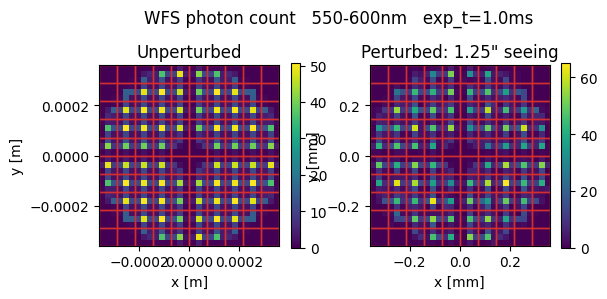

In [116]:
plt.suptitle(f'WFS photon count   {int(wfs_min*1e9)}-{int(wfs_max*1e9)}nm   exp_t={round(wfs_exp_time*1e3,2)}ms', y= 0.8)

noise_calm = large_poisson(photon_counts_calm).astype('float') # seems to give 0
#diff = photon_counts_calm - noise_calm
#print(np.max(photon_counts_calm/noise_calm), np.min(photon_counts_calm/noise_calm))

plt.subplot(1,2,1)
imshow_field(photon_counts_calm, vmin = 0)#, vmax = np.max(photon_image_calm))
plt.title(f'Unperturbed')
plt.gca().set_aspect(1)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
for p in grid.points:
    d = grid.x[1]-grid.x[0]
    rect = plt.Rectangle(p - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.colorbar(shrink=0.5)

plt.subplot(1,2,2)
imshow_field(noise_calm, grid_units=1e-3, vmin = 0)#, vmax = np.max(photon_image_calm))
plt.title(f'Perturbed: {seeing}" seeing')
plt.gca().set_aspect(1)
plt.xlabel('x [mm]')
plt.ylabel('y [mm]')
for p in grid.points:
    d = (grid.x[1]-grid.x[0])*1e3
    rect = plt.Rectangle(p*1e3 - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.colorbar(shrink=0.5)

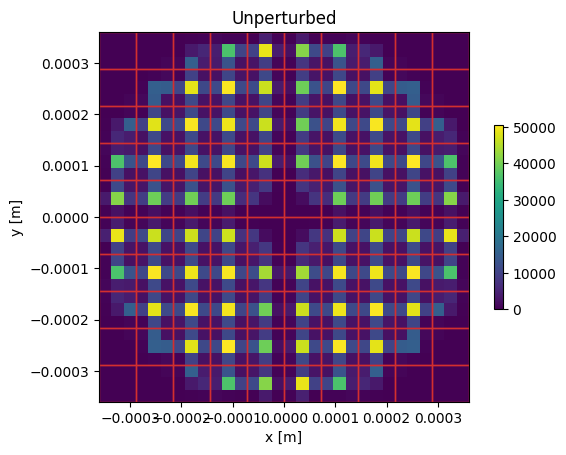

In [117]:
imshow_field(photon_counts_ref, vmin = 0, vmax = np.max(photon_counts_ref))
plt.title(f'Unperturbed')
plt.gca().set_aspect(1)
plt.xlabel('x [m]')
plt.ylabel('y [m]')
for p in grid.points:
    d = grid.x[1]-grid.x[0]
    rect = plt.Rectangle(p - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
    plt.gca().add_patch(rect)
plt.colorbar(shrink=0.5)

In [118]:
# pick which subapertures are illuminated enough to actually use

shwfse = ShackHartmannWavefrontSensorEstimator(shwfs.mla_grid, shwfs.micro_lens_array.mla_index)

fluxes = ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)
flux_limit = fluxes.max() * 0.75

estimation_subapertures = shwfs.mla_grid.zeros(dtype='bool')
estimation_subapertures[shwfse.estimation_subapertures[fluxes > flux_limit]] = True

shwfse = ShackHartmannWavefrontSensorEstimator(shwfs.mla_grid, shwfs.micro_lens_array.mla_index, estimation_subapertures)

print(f'Using {len(shwfse.estimation_subapertures)}/{num_lenslets**2} subapertures for slope estimation.')
print(f'Avg. photon count per (illuminated) subaperture: {round(np.mean(ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)),1)}')


Using 53/100 subapertures for slope estimation.
Avg. photon count per (illuminated) subaperture: 95305.4


/var/folders/c6/3j4rmdms4vbfk4qv_kpw36_h0000gn/T/ipykernel_1293/1544894866.py:5: DeprecationWarning: Please import `sum` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  fluxes = ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)
/var/folders/c6/3j4rmdms4vbfk4qv_kpw36_h0000gn/T/ipykernel_1293/1544894866.py:14: DeprecationWarning: Please import `sum` from the `scipy.ndimage` namespace; the `scipy.ndimage.measurements` namespace is deprecated and will be removed in SciPy 2.0.0.
  print(f'Avg. photon count per (illuminated) subaperture: {round(np.mean(ndimage.measurements.sum(photon_counts_ref, shwfse.mla_index, shwfse.estimation_subapertures)),1)}')


In [119]:
##### get slopes for the unperturbed wavefront 

slopes_ref = shwfse.estimate([photon_counts_ref]) # can I use photon counts as a unit for slope estimation?

In [120]:
# choose number of actuators for DM <-> select number of correctable AO modes

num_actuators = (telescope_diameter/fried_parameter)**2
num_modes = int(round(num_actuators,0))
print(num_modes)

dm_modes = make_zernike_basis(num_modes=num_modes, 
                              D=telescope_diameter,
                              grid=pupil_grid, 
                             use_cache=False) # btw: harmonic disk basis uses fourier bessel basis functions
dm_modes = ModeBasis([mode / np.ptp(mode) for mode in dm_modes], pupil_grid)

98


In [121]:
deformable_mirror = DeformableMirror(dm_modes)

In [122]:
# calibrate interaction matrix 
# for this, excite each mode individually and log what happens to the centroids on the detector

probe_amp = 0.5 * telescope_diameter / 2 * np.sin(fov_wfs/3600) * magnification_pupil #0.2e-6 # * wavelength_wfs # meters
print(probe_amp)
response_matrix = []

wf = Wavefront(telescope_pupil, wavelength_wfs)
wf.total_power = 1

# Set up animation
fig = plt.figure(figsize=(10, 6))
writer = FFMpegWriter(
    fps=2,
    metadata={"title": "DM Response Matrix"},
    bitrate=1800
)
output_file = "response_matrix2.mp4"

deformable_mirror.flatten()

with writer.saving(fig, output_file, dpi=100):

    for i in tqdm(range(num_modes)):
        slope = 0
    
        # Probe the phase response
        amps = [-probe_amp, probe_amp]
        for amp in amps:
            deformable_mirror.flatten()
            deformable_mirror.actuators[i] = amp
    
            dm_wf = deformable_mirror.forward(wf)
            wfs_wf = shwfs(magnifier(dm_wf))

            camera.integrate(wfs_wf, 1)
            image = camera.read_out()
    
            slopes = shwfse.estimate([image])
    
            slope += amp * slopes / np.var(amps)
    
        response_matrix.append(slope.ravel())
    
        # Only show all modes for the first 40 modes
        if i > 40 and (i + 1) % 20 != 0:
            continue
    
        # Plot mode response
        plt.clf()
        plt.suptitle('Mode %d / %d' % (i + 1, num_modes), y=0.87)
    
        plt.subplot(1,2,1)
        plt.title('DM surface')
        im1 = imshow_field(deformable_mirror.surface, cmap='RdBu', mask=telescope_pupil)
    
        plt.subplot(1,2,2)
        plt.title('SH spots (slopes not to scale)')
        im2 = imshow_field(image)
        plt.quiver(shwfs.mla_grid.subset(shwfse.estimation_subapertures).x,
            shwfs.mla_grid.subset(shwfse.estimation_subapertures).y,
            slope[0,:], slope[1,:],
            color='white')
    
        writer.grab_frame()

response_matrix = ModeBasis(response_matrix)

plt.close(fig)
print(f"Animation saved to: {output_file}")

2.4999991962449337e-07


  0%|          | 0/98 [00:00<?, ?it/s]

Animation saved to: response_matrix2.mp4


In [123]:
# invert the response matrix to get a function that takes slope as input and gives actuator movement as output

rcond = 1e-3

reconstruction_matrix = inverse_tikhonov(response_matrix.transformation_matrix, rcond=rcond)

In [125]:
# Close the loop, with atmosphere

layer.reset()
deformable_mirror.flatten()

t_atmos = 0.001
sci_exp_time = 0.006 # 0.006s -> 150fps for LEO

include_photon_noise = True

gain = 0.0075 # kind of like percent of phase change relative to probe_amp we expect in one time step t_atmos?
leakage = 0.01
num_iterations = 350
playback_speed = 0.1

fig = plt.figure(figsize=(12, 8))
writer = FFMpegWriter(
    fps=int(playback_speed / t_atmos),
    metadata={"title": "Closing the Loop with turbulent atmosphere"},
    bitrate=1800
)
output_file = f"AO_{int(operation_freq)}Hz_WFS{int(wfs_min*1e10)}A_{int(wfs_max*1e10)}A_Sci{int(sci_min*1e10)}A_{int(sci_max*1e10)}A_BS{int(wfs_beamsplit*100)}pct_SC{sci_exp_time}s_exptime_r0{int(fried_parameter*1e2)}cm_gain{gain}_stroke{round(probe_amp*1e6,2)}microns_{num_iterations}iter_photonnoise_{include_photon_noise}.mp4"

strehls = []
strehls_uncorr = []

wfs_energy = 0
wfs_photon_image = 0
counts_per_angstr_turb = np.zeros((len(wfs_wavefronts), n_pixels_wfs))
photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)


with writer.saving(fig, output_file, dpi=100):
    
    for timestep in tqdm(range(num_iterations)):
        
        layer.t = timestep * t_atmos
        
        phase_screen_phase = layer.phase_for(wavelength_wfs) # in radian
        phase_screen_opd = phase_screen_phase * (wavelength_wfs / (2 * np.pi)) * 1e6 # in um
    
        # WFS: Propagate through atmosphere, deformable mirror, and SHWFS
        for i, wf in enumerate(wfs_wavefronts):

            E_photon = h * c / (wf.wavelength*1e10) # erg
            camera.integrate(shwfs(magnifier(deformable_mirror(layer(wf)))), t_atmos) 
            wfs_data = camera.read_out()
            counts_per_angstr_turb[i] = wfs_data / E_photon

        for i in range(len(counts_per_angstr_turb[0])): # loop over pixels, integrate all wavelengths
            photon_counts_turb[i] += integrate.simpson(counts_per_angstr_turb[:, i], wfs_wls)

        if int(layer.t*10000) % int(wfs_exp_time*10000) == 0:
            wfs_photon_image_to_plot = photon_counts_turb
            photon_counts_turb = Field(np.zeros(len(counts_per_angstr_ref[0])), focal_grid_wfs)

        psf_ref = 0
        for wf in sci_wavefronts:
            sci_camera.integrate(prop(layer(wf)), t_atmos) # uncorrected
            sci_camera2.integrate(prop(deformable_mirror(layer(wf))), t_atmos) # corrected
            psf_ref += prop.forward(wf).power*sci_exp_time #*prop.forward(wf).wavelength*1e10*5.03e7

        if int(layer.t*1000) % int(sci_exp_time*1000) == 0: # modulo behaves weird with decimals

            psf_uncorr = sci_camera.read_out()
            psf_corr = sci_camera2.read_out()
        
            strehl = float(get_strehl_from_focal(psf_corr, psf_ref))
            strehl_uncorr = float(get_strehl_from_focal(psf_uncorr, psf_ref))
            if timestep/num_iterations > 0.05:# and timestep/num_iterations < 0.95: # cut off weird temporal edge behavior
                strehls.append(strehl)
                strehls_uncorr.append(strehl_uncorr)
                
                    
        # Calculate slopes from WFS image
        #wfs_img = large_poisson(wfs_img).astype('float')
        if include_photon_noise:
            wfs_photon_image_to_plot = large_poisson(wfs_photon_image_to_plot).astype('float')
        slopes = shwfse.estimate([wfs_photon_image_to_plot + 1e-20])
        slopes -= slopes_ref
        slopes = slopes.ravel()
    
        # Perform wavefront control and set DM actuators
        deformable_mirror.actuators = (1 - leakage) * deformable_mirror.actuators - gain * reconstruction_matrix.dot(slopes)

        # plot: atmosphere, DM, WFS image, corr focal image, uncorr focal image
    
        # Plotting
        if timestep % 1 == 0: # can make this more coarse if needed
            plt.clf()
    
            plt.suptitle(f'Gain: {gain}  PSF at $\\lambda$={round(wavelength_sci*1e6,2)}µm  WFS at $\\lambda$={round(wavelength_wfs*1e6,2)}µm  DM stroke: {round(probe_amp*1e6,2)}µm  WFS freq = {operation_freq}Hz  t = {round(layer.t,3)}  S={round(strehl,2)}', y = 0.92)
            plt.subplots_adjust(wspace=0.5) 
            
            plt.subplot(2,3,1)
            plt.title('DM OPD [$\\mu$m]')
            imshow_field(deformable_mirror.surface * 1e6, cmap='RdBu', vmin=-6, vmax=6, mask=telescope_pupil)
            plt.colorbar()
            plt.xlabel('x [m]')
            plt.ylabel('y [m]')
    
            plt.subplot(2,3,2)
            plt.title('WFS image [counts]')
            imshow_field(wfs_photon_image_to_plot, vmin=0, vmax=np.max(wfs_photon_image_to_plot), grid_units=1e-3)
            plt.colorbar()
            for p in grid.points:
                d = (grid.x[1]-grid.x[0])*1e3
                rect = plt.Rectangle(p*1e3 - d/ 2, d, d, linewidth=1, edgecolor=colors.red, facecolor='none')
                plt.gca().add_patch(rect)
            plt.xlabel('x [mm]')
            plt.ylabel('y [mm]')
    
            plt.subplot(2,3,3)
            plt.title(f'AO-Corr. PSF $\\mu$m [log]')
            imshow_field(np.log10(psf_corr/psf_corr.max()), vmin=-5, vmax=0, grid_units=1e-6) 
            plt.colorbar()
            plt.xlabel('x [µm]')
            plt.ylabel('y [µm]')

            plt.subplot(2,3,4)
            plt.title(f'Uncorr. PSF $\\mu$m [log]')
            imshow_field(np.log10(psf_uncorr/psf_uncorr.max()), vmin=-5, vmax=0, grid_units=1e-6) 
            plt.colorbar()
            plt.xlabel('x [µm]')
            plt.ylabel('y [µm]')

            plt.subplot(2,3,5)
            plt.title('Atmosph. OPD [$\\mu$m]')
            imshow_field(phase_screen_opd, vmin=-6, vmax=6, cmap='RdBu')
            plt.colorbar()
            plt.xlabel('x [m]')
            plt.ylabel('y [m]')
            

        writer.grab_frame()
        
plt.close(fig)
print(f"Animation saved to: {output_file}")

strehl_ao = np.mean(strehls)
strehl_noao = np.mean(strehls_uncorr)

# save results

fields=['seeing', 'r0', 'v', 'n_actuators', 'n_lenslets', 'SH_FOV', 'WFS_exp_time', 'WFS_lambda_min', 'WFS_lambda_max',
        'SC_exp_time', 'SC_lambda_min', 'SC_lambda_max', 'beamsplit', 'DM_stroke', 'photon_noise', 'Strehl_noAO', 'Strehl_AO']   

new_row = {'seeing': seeing,
           'r0': fried_parameter, 
           'v': velocity, 
           'n_actuators': num_actuators,
           'n_lenslets': num_lenslets,
           'SH_FOV': fov_wfs,
           'WFS_exp_time': wfs_exp_time, 
           'WFS_lambda_min': wfs_min, 
           'WFS_lambda_max': wfs_max, 
           'SC_exp_time': sci_exp_time, 
           'SC_lambda_min': sci_min, 
           'SC_lambda_max': sci_max, 
           'beamsplit': wfs_beamsplit, 
           'DM_stroke': probe_amp,
           'photon_noise': include_photon_noise,
           'Strehl_noAO': strehl_noao, 
           'Strehl_AO': strehl_ao}

with open('ao_performances2.txt', 'a') as f:
    writer = DictWriter(f, fieldnames=fields)
    writer.writerow(new_row)

  0%|          | 0/350 [00:00<?, ?it/s]

Animation saved to: AO_1000Hz_WFS5500A_6000A_Sci4000A_5500A_BS100pct_SC0.006s_exptime_r08cm_gain0.0075_stroke0.25microns_350iter_photonnoise_True.mp4
